# Classificação Supervisionada com Fuzzy C-Means no Dataset Dry Bean (Balanceado)

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Fuzzy C-Means, aplicado ao dataset Dry Bean com balanceamento das classes via oversampling. Todas as etapas são explicadas e o código é comentado para facilitar o entendimento.

## 1. Importação das Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import skfuzzy as fuzz
import os
from sklearn.decomposition import PCA

os.makedirs('img', exist_ok=True)

## 2. Carregamento e Balanceamento dos Dados

O dataset Dry Bean é carregado e as classes minoritárias são balanceadas por oversampling, igualando a quantidade de exemplos de todas as classes. Isso evita que o modelo favoreça as classes majoritárias.

In [2]:
bean_df = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')
bean_df = bean_df.dropna()

print('Distribuição original das classes:')
print(bean_df['Class'].value_counts())

# Balanceamento por oversampling (todas as classes terão o mesmo número de exemplos da classe majoritária)
max_count = bean_df['Class'].value_counts().max()
bean_df_balanced = pd.DataFrame()
for label in bean_df['Class'].unique():
    df_class = bean_df[bean_df['Class'] == label]
    df_upsampled = resample(df_class, replace=True, n_samples=max_count, random_state=42)
    bean_df_balanced = pd.concat([bean_df_balanced, df_upsampled])
bean_df_balanced = bean_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print('Distribuição após balanceamento:')
print(bean_df_balanced['Class'].value_counts())

Distribuição original das classes:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64
Distribuição após balanceamento:
Class
BARBUNYA    3546
CALI        3546
BOMBAY      3546
SIRA        3546
DERMASON    3546
SEKER       3546
HOROZ       3546
Name: count, dtype: int64


## 3. Pré-processamento dos Dados

In [3]:
for col in bean_df_balanced.select_dtypes(include='object').columns:
    bean_df_balanced[col] = LabelEncoder().fit_transform(bean_df_balanced[col].astype(str))
X = bean_df_balanced.drop('Class', axis=1).values
y = bean_df_balanced['Class'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)

## 4. Divisão dos Dados em Treino e Teste

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 5. Definição do Número de Clusters (Método do Cotovelo)

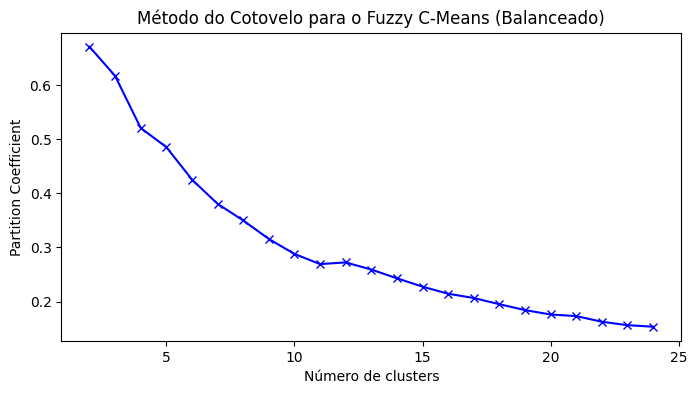

In [5]:
partition_coeffs = []
K = range(2, 25)
for k in K:
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_train.T, c=k, m=2, error=0.005, maxiter=1000, seed=42)
    pc = np.sum(u ** 2) / u.shape[1]
    partition_coeffs.append(pc)

plt.figure(figsize=(8,4))
plt.plot(K, partition_coeffs, 'bx-')
plt.xlabel('Número de clusters')
plt.ylabel('Partition Coefficient')
plt.title('Método do Cotovelo para o Fuzzy C-Means (Balanceado)')
plt.savefig('img/cmeans_drybean_balance_elbow.png')
plt.show()

## 6. Implementação do Classificador Fuzzy C-Means Supervisionado

In [6]:
class FuzzyCMeansSupervisionado:
    def __init__(self, n_clusters=2, m=2, random_state=0):
        self.n_clusters = n_clusters
        self.m = m
        self.random_state = random_state
        self.centers_ = None
        self.cluster_labels_ = None

    def fit(self, X, y):
        cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
            X.T, c=self.n_clusters, m=self.m, error=0.005, maxiter=1000, seed=self.random_state)
        self.centers_ = cntr
        labels = np.argmax(u, axis=0)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (labels == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        u, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
            X.T, self.centers_, m=self.m, error=0.005, maxiter=1000)
        clusters = np.argmax(u, axis=0)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 7. Treinamento e Avaliação do Classificador

Acurácia: 0.8484
Matriz de Confusão:
[[ 891    0   35   11    6   23   97]
 [   0 1064    0    0    0    0    0]
 [ 114    0  892    1   23    0   34]
 [   3    0    0  923    2   66   70]
 [   0    0  157    4  879    0   24]
 [   1    0    0  102    0  950   11]
 [   4    0   13  296   27    5  719]]


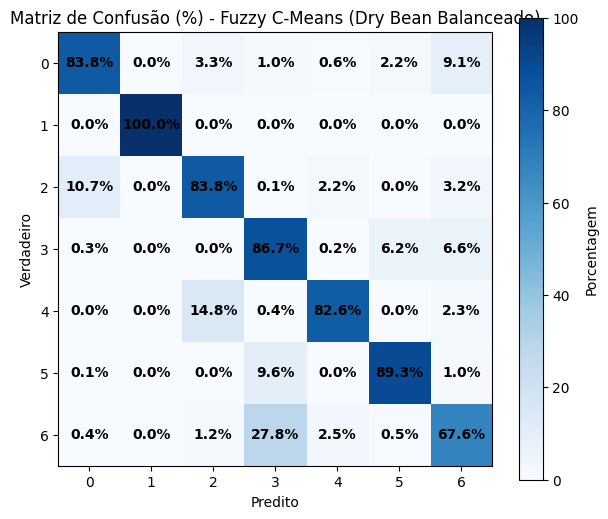

In [7]:
n_clusters = 7  # Ajuste conforme o gráfico do cotovelo

clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=42)
clf.fit(X_train, y_train)

acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(7,6))
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
plt.imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão (%) - Fuzzy C-Means (Dry Bean Balanceado)')
plt.colorbar(label='Porcentagem')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        plt.text(j, i, f'{cm_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.savefig('img/cmeans_drybean_balance_confusion_matrix.png')
plt.show()

## 8. Repetição dos Experimentos e Métricas

Acurácia média: 0.8424
Desvio padrão da acurácia: 0.0205
MSE médio: 1.5576
Desvio padrão do MSE: 0.2381
Matriz de confusão média (percentual):
[[ 82.3   0.    4.7   1.    0.8   1.5   9.6]
 [  0.  100.    0.    0.    0.    0.    0. ]
 [ 10.    0.   84.2   0.2   2.2   0.3   3.1]
 [  0.2   0.    0.   86.5   0.2   5.3   7.8]
 [  0.2   0.   13.8   0.5  83.1   0.    2.5]
 [  0.2   0.    0.    8.7   0.   89.8   1.2]
 [  1.4   0.    1.3  31.2   1.7   0.6  63.9]]


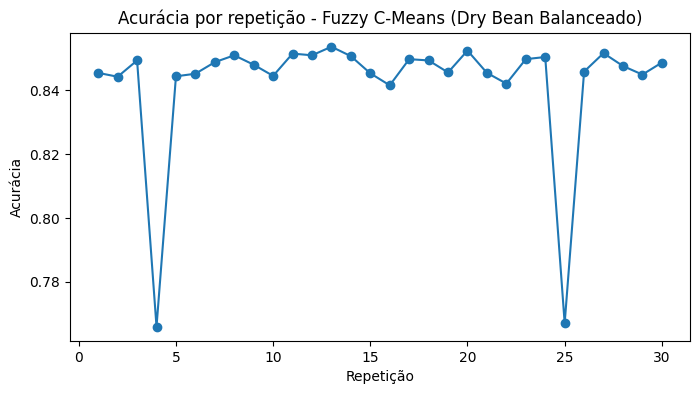

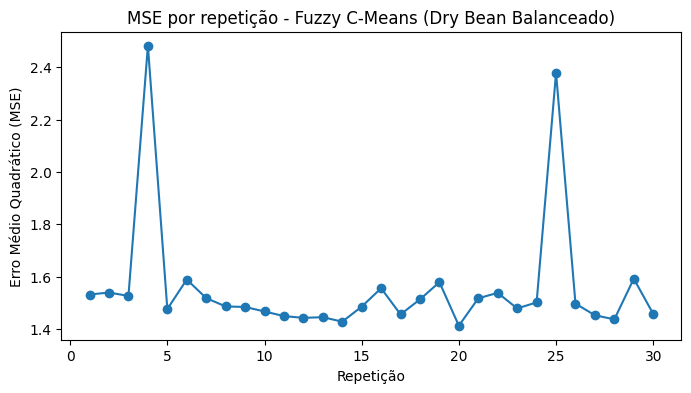

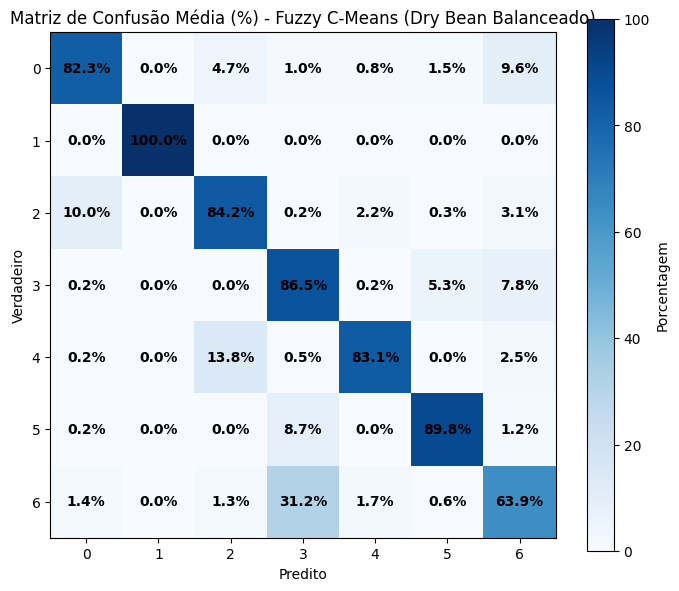

In [8]:
acuracias = []
mse_list = []
matrizes_confusao = []
from sklearn.metrics import mean_squared_error, confusion_matrix
classes = np.unique(y)
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    acuracias.append(acc)
    mse_list.append(mse)
    matrizes_confusao.append(confusion_matrix(y_test, y_pred, labels=classes))

acuracias = np.array(acuracias)
mse_array = np.array(mse_list)
matrizes_confusao = np.array(matrizes_confusao)
matriz_confusao_media = np.mean(matrizes_confusao, axis=0)
matriz_confusao_media_percent = matriz_confusao_media / matriz_confusao_media.sum(axis=1, keepdims=True) * 100

print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')
print("Matriz de confusão média (percentual):")
print(np.round(matriz_confusao_media_percent, 1))

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - Fuzzy C-Means (Dry Bean Balanceado)')
plt.savefig('img/cmeans_drybean_balance_accuracy_repetitions.png')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(range(1, 31), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - Fuzzy C-Means (Dry Bean Balanceado)')
plt.savefig('img/cmeans_drybean_balance_mse_repetitions.png')
plt.show()

plt.figure(figsize=(7,6))
plt.imshow(matriz_confusao_media_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão Média (%) - Fuzzy C-Means (Dry Bean Balanceado)')
plt.colorbar(label='Porcentagem')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
for i in range(matriz_confusao_media_percent.shape[0]):
    for j in range(matriz_confusao_media_percent.shape[1]):
        plt.text(j, i, f'{matriz_confusao_media_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('img/cmeans_drybean_balance_confusion_matrix_media_percent.png')
plt.show()

# Salvar resultados para análise posterior
np.save('img/cmeans_drybean_balance_accuracies.npy', acuracias)
np.savetxt('img/cmeans_drybean_balance_accuracies.csv', acuracias, delimiter=',')
np.save('img/cmeans_drybean_balance_mse_repetitions.npy', mse_array)
np.savetxt('img/cmeans_drybean_balance_mse_repetitions.csv', mse_array, delimiter=',')
np.save('img/cmeans_drybean_balance_confusion_matrix_media_percent.npy', matriz_confusao_media_percent)
np.savetxt('img/cmeans_drybean_balance_confusion_matrix_media_percent.csv', matriz_confusao_media_percent, delimiter=',')

## 9. Cálculo das Principais Métricas de Avaliação

## 10. Análise Crítica dos Resultados e Métricas

Nesta etapa, analisamos criticamente os resultados obtidos pelo classificador Fuzzy C-Means no dataset DryBean balanceado. As principais métricas (acurácia, precisão, recall, especificidade, F1-score e matriz de confusão média) permitem avaliar o desempenho do modelo de forma quantitativa e qualitativa.

- **Acurácia média e desvio padrão:** Avaliam o desempenho global e a estabilidade do modelo frente a diferentes divisões dos dados.
- **Matriz de confusão média:** Permite visualizar como os clusters encontrados se relacionam com as classes reais, identificando acertos e erros do agrupamento.
- **Precisão, recall, especificidade e F1-score:** Complementam a análise, mostrando o comportamento do modelo em relação a cada classe.

**Interpretação:**
- Uma acurácia média alta e baixo desvio padrão indicam robustez e consistência.
- Padrões diagonais na matriz de confusão sugerem boa correspondência entre clusters e classes reais.
- Métricas equilibradas indicam que o balanceamento foi eficaz e o modelo não favorece uma classe específica.

**Sugestões:**
- Compare os resultados do Fuzzy C-Means com outros métodos (KMeans, Agglomerative, GK) para avaliar qual abordagem é mais adequada ao problema.
- Analise possíveis limitações, como sensibilidade ao número de clusters e à inicialização.
- Considere a visualização dos agrupamentos (PCA) para interpretar a separação dos grupos no espaço de atributos.

Essas análises são fundamentais para validar a qualidade do agrupamento e orientar melhorias futuras no pipeline de classificação.

Acurácia média: 0.8424
Precisão média: 0.8437
Recall médio: 0.8424
Especificidade média: 0.9737
F1-score médio: 0.8404
Matriz de confusão média:
[[8.75870e+02 0.00000e+00 5.02700e+01 1.08000e+01 9.00000e+00 1.55000e+01
  1.02570e+02]
 [0.00000e+00 1.06387e+03 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00]
 [1.06400e+02 7.00000e-02 8.95400e+02 2.50000e+00 2.38700e+01 2.77000e+00
  3.28300e+01]
 [2.33000e+00 0.00000e+00 0.00000e+00 9.19800e+02 2.53000e+00 5.64300e+01
  8.27700e+01]
 [1.67000e+00 0.00000e+00 1.47030e+02 5.33000e+00 8.83570e+02 0.00000e+00
  2.61300e+01]
 [2.50000e+00 0.00000e+00 2.70000e-01 9.28000e+01 0.00000e+00 9.55230e+02
  1.31300e+01]
 [1.52300e+01 0.00000e+00 1.42300e+01 3.31370e+02 1.77700e+01 5.87000e+00
  6.79300e+02]]


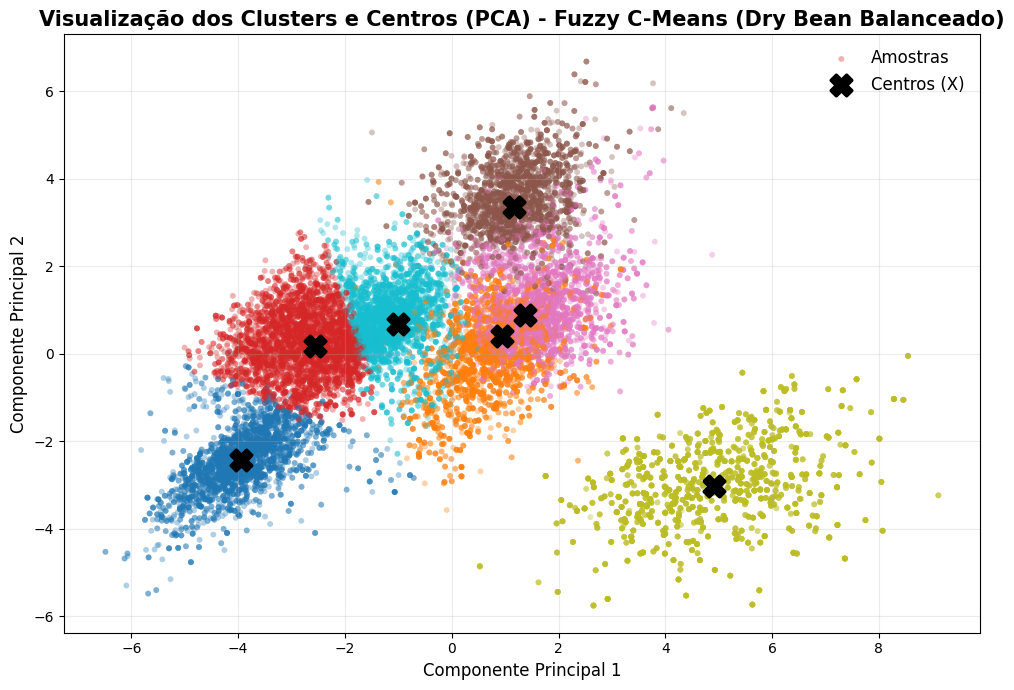

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

def calcular_metricas_multiclasse(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    # Especificidade média: média das especificidades de cada classe
    especificidades = []
    for i in range(cm.shape[0]):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        especificidades.append(especificidade)
    especificidade_media = np.mean(especificidades)
    return acc, prec, rec, especificidade_media, f1, cm

# Repetição para obter métricas médias
accs, precs, recs, especificidades, f1s, cms = [], [], [], [], [], []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc, prec, rec, esp, f1, cm = calcular_metricas_multiclasse(y_test, y_pred)
    accs.append(acc)
    precs.append(prec)
    recs.append(rec)
    especificidades.append(esp)
    f1s.append(f1)
    cms.append(cm)

print(f'Acurácia média: {np.mean(accs):.4f}')
print(f'Precisão média: {np.mean(precs):.4f}')
print(f'Recall médio: {np.mean(recs):.4f}')
print(f'Especificidade média: {np.mean(especificidades):.4f}')
print(f'F1-score médio: {np.mean(f1s):.4f}')
print('Matriz de confusão média:')
print(np.mean(cms, axis=0).round(2))

# Redução de dimensionalidade para 2D com PCA (antes do clustering)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Executa o Fuzzy C-Means para obter os clusters e centros
clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=42)
clf.fit(X, y)
u, _, _, _, _, _ = fuzz.cluster.cmeans_predict(X.T, clf.centers_, m=2, error=0.005, maxiter=1000)
clusters = np.argmax(u, axis=0)
centros_pca = pca.transform(clf.centers_)

# Gráfico 2D dos clusters e centros (X em preto)
plt.figure(figsize=(10,7))
plt.scatter(
    X_pca[:,0], X_pca[:,1], 
    c=clusters, cmap='tab10', alpha=0.35, s=18, edgecolor='none', label='Amostras'
)
plt.scatter(
    centros_pca[:,0], centros_pca[:,1], 
    c='black', marker='X', s=220, linewidths=2.5, zorder=4, label='Centros (X)'
)
plt.title('Visualização dos Clusters e Centros (PCA) - Fuzzy C-Means (Dry Bean Balanceado)', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(alpha=0.25)
plt.legend(frameon=False, fontsize=12, loc='best')
plt.tight_layout()
plt.savefig('img/cmeans_drybean_balance_clusters_pca.png', dpi=150)
plt.show()